# 03 – Feature Engineering
Derive two features, `distanceToCapital` and `pricePerSquare`, and explore how they relate to other variables.

**Input:** `housing_no_outlier.csv` · **Output:** `data/processed/housing_extended.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Path('../reports/figures').mkdir(parents=True, exist_ok=True)

housing_no_outlier = pd.read_csv('../data/processed/housing_no_outlier.csv', encoding='gbk')
housing_no_outlier.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7
2,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6
3,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1
4,116.466280,39.991363,2016-07-22,861.0,275.6,53.00,1,0,1,1,8,2005,Simplicity,steel-concrete composite,0.333,has elevator,no subway,7


## Distance to the city center
Great-circle distance from each property to the center of Beijing (116.4074°E, 39.9042°N), using the spherical law of cosines with Earth radius R = 6371.0088 km:

$$d = R \cdot \arccos\big(\sin\varphi_1 \sin\varphi_2 + \cos\varphi_1 \cos\varphi_2 \cos(\lambda_2 - \lambda_1)\big)$$

where φ is latitude and λ is longitude, all in radians (vectorized with `np.radians`).

In [2]:
from math import radians
capital_Lng = radians(116.4074)
capital_Lat = radians(39.9042)

housing_capital = housing_no_outlier.copy()
lat = np.radians(housing_capital['Lat'])
lng = np.radians(housing_capital['Lng'])

housing_capital['distanceToCapital'] = (
    np.arccos(
        np.sin(lat) * np.sin(capital_Lat)
        + np.cos(lat) * np.cos(capital_Lat)
        * np.cos(lng - capital_Lng)
    ) * 6371.0088
)

housing_capital.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district,distanceToCapital
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7,14.074996
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7,4.701224
2,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6,19.293041
3,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1,2.683335
4,116.466280,39.991363,2016-07-22,861.0,275.6,53.00,1,0,1,1,8,2005,Simplicity,steel-concrete composite,0.333,has elevator,no subway,7,10.914652


## Price per square meter
`pricePerSquare = totalPrice / square × 1000`. The ×1000 scale factor follows the original assignment specification; it does not affect relative comparisons.

In [3]:
housing_PPS = housing_capital.copy()

housing_PPS['pricePerSquare'] = (
    housing_PPS['totalPrice'] / housing_PPS['square'] * 1000
)

housing_PPS.head()

,Lng,Lat,tradeTime,DOM,totalPrice,square,livingRoom,drawingRoom,kitchen,bathRoom,floor,constructionTime,renovationCondition,buildingStructure,ladderRatio,elevator,subway,district,distanceToCapital,pricePerSquare
0,116.475489,40.019520,2016-08-09,1464.0,415.0,131.00,2,1,1,1,26,2005,Simplicity,steel-concrete composite,0.217,has elevator,has subway,7,14.074996,3167.938931
1,116.453917,39.881534,2016-07-28,903.0,575.0,132.38,2,2,1,2,22,2004,hardcover,steel-concrete composite,0.667,has elevator,no subway,7,4.701224,4343.556428
2,116.438010,40.076114,2016-09-30,965.0,297.5,134.00,3,1,1,1,21,2008,other,steel-concrete composite,0.273,has elevator,no subway,6,19.293041,2220.149254
3,116.428392,39.886229,2016-08-28,927.0,392.0,81.00,2,1,1,1,6,1960,rough,mixed,0.333,no elevator,has subway,1,2.683335,4839.506173
4,116.466280,39.991363,2016-07-22,861.0,275.6,53.00,1,0,1,1,8,2005,Simplicity,steel-concrete composite,0.333,has elevator,no subway,7,10.914652,5200.000000


## Distributions of numeric features

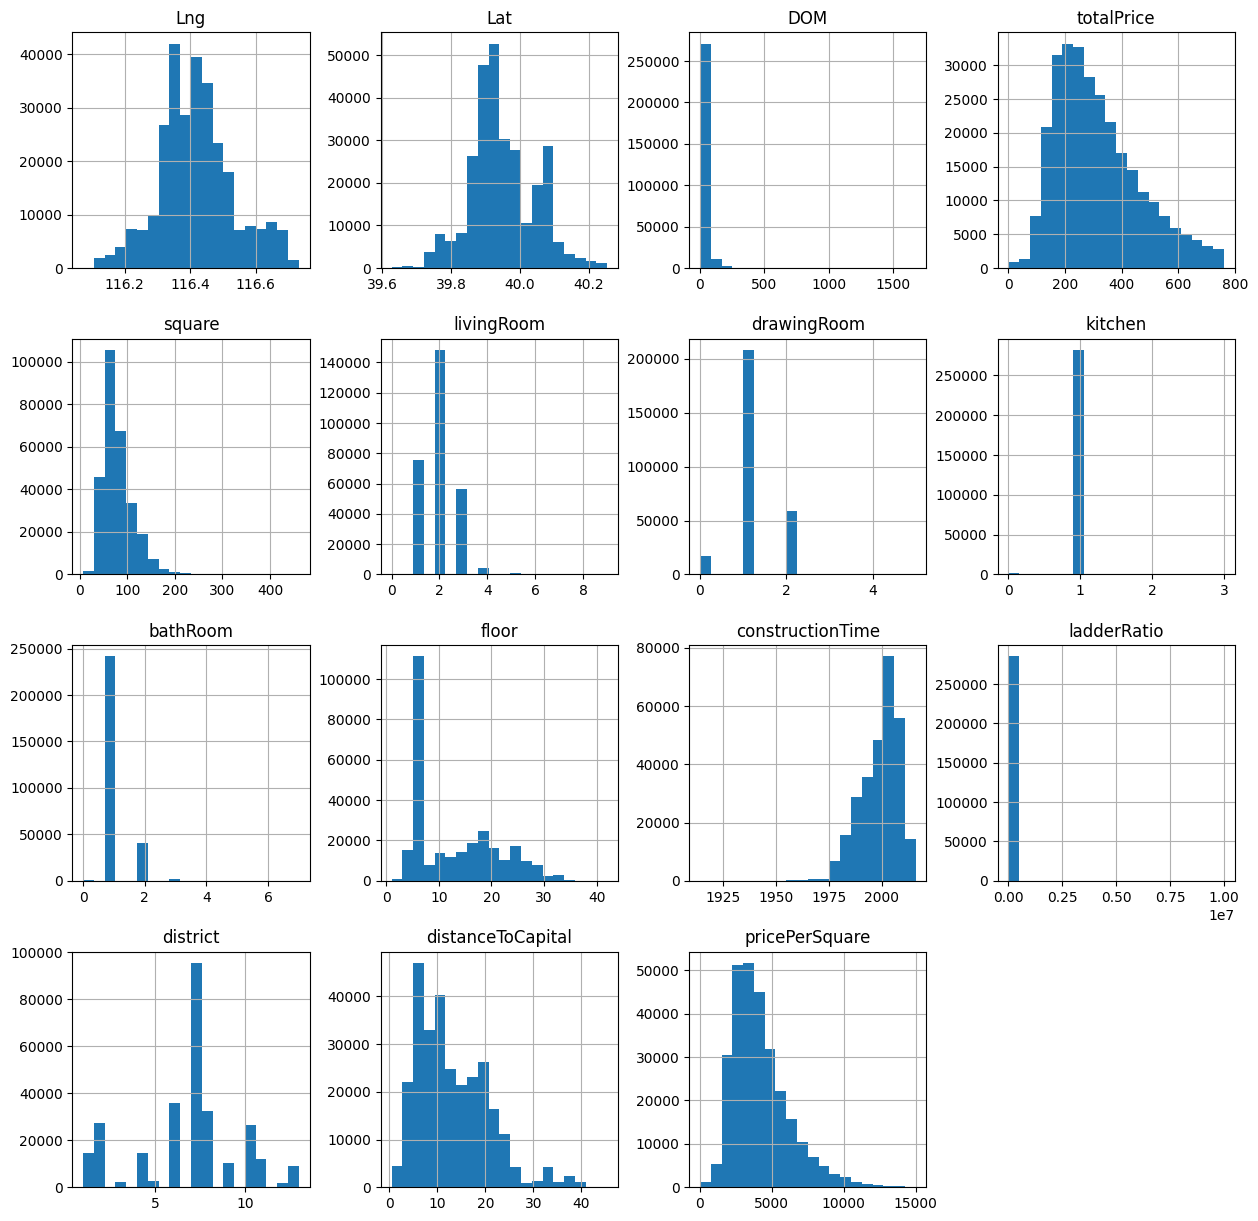

In [4]:
fig1 , ax1 = plt.subplots()
fig1.set_size_inches(15,15)
housing_PPS.hist(ax = ax1, bins = 20);

## Price per m² vs. distance to the center
Scatter plot with a fitted regression line.

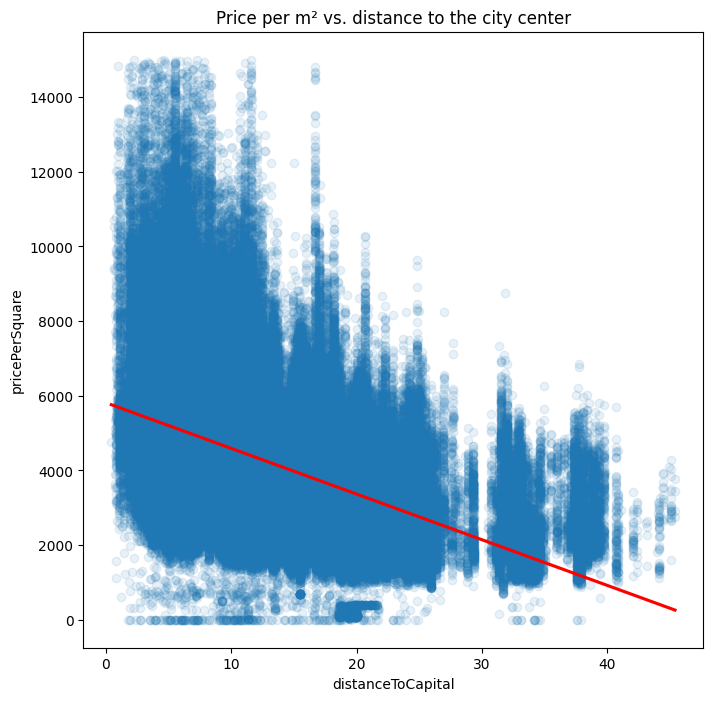

In [5]:
fig, ax = plt.subplots(figsize=(8, 8))

# ci=None skips the bootstrapped confidence band, which is slow on ~300k points
sns.regplot(ax=ax, data=housing_PPS, x='distanceToCapital', y='pricePerSquare', ci=None,
            line_kws={'color': 'red'}, scatter_kws={'alpha': 0.1})
ax.set_title('Price per m² vs. distance to the city center')
fig.savefig('../reports/figures/price_vs_distance.png', dpi=130, bbox_inches='tight');

## Effect of elevator availability
Kernel density estimates of `pricePerSquare` for properties with and without an elevator. `elevator` holds string labels (`'has elevator'` / `'no elevator'`), not 0/1.

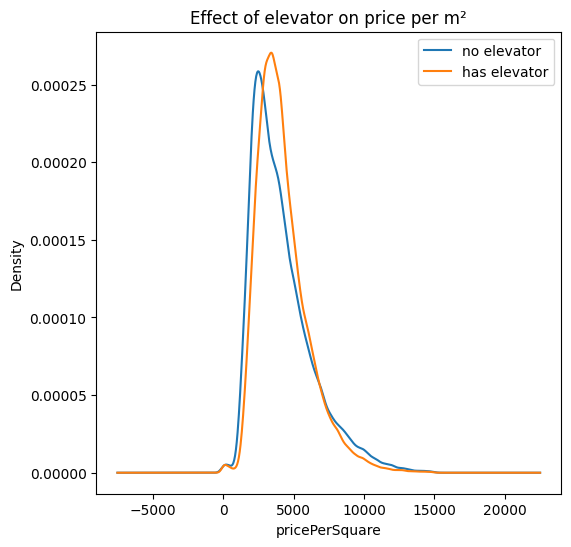

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))

for label in ['no elevator', 'has elevator']:
    housing_PPS.loc[housing_PPS['elevator'] == label, 'pricePerSquare'].plot(kind='density', ax=ax, label=label)

ax.set_title('Effect of elevator on price per m²')
ax.set_xlabel('pricePerSquare')
ax.legend()
fig.savefig('../reports/figures/elevator_density.png', dpi=130, bbox_inches='tight');

## Save

In [7]:
housing_PPS.to_csv('../data/processed/housing_extended.csv', encoding='gbk', index=False)